# HIV transcription foci: slice-wise background subtraction, projection, and auto-thresholding

Goal: segment bright HIV transcription foci against dimmer diffuse cytoplasmic signal.

Pipeline (one processing cell, one QC cell):
1. Load a multi-dimensional TIF and keep the selected channel
2. Max-intensity Z-project the **raw** channel (kept only for the QC plot)
3. Rolling-ball background subtraction (a port of ImageJ's *Subtract Background*)
4. Median filter (denoising, so the threshold sees a cleaner histogram)
5. Max-intensity Z-project, if it has not happened already -- see the two modes below
6. Convert 16-bit -> 8-bit (this is the input to thresholding)
7. Try all auto-threshold methods
8. Fill holes in every mask (ImageJ Binary > Fill Holes)
9. Apply the chosen threshold and show a 4-panel QC plot

**Two modes**, set by `PARAMS.mode`, differing only in where the Z-projection happens:

| mode | order | cost |
| --- | --- | --- |
| `"2d"` (default) | project -> rolling ball -> median | ~6 s / file |
| `"3d"` | rolling ball -> median *per slice* -> project | ~60 s / file |

`"3d"` removes each plane's own out-of-focus haze and pulls every slice to a zero baseline
before they compete in the max, so it flattens the background hardest.

Background subtraction uses `src/imagej_rolling_ball.py`, a port of ImageJ's
*Subtract Background* (3x3 presmooth, block-minimum shrink, grayscale opening with a trimmed
ball patch, bilinear enlarge). `skimage.restoration.rolling_ball` is not equivalent: it
returns the height of the ball *centre* rather than its surface and has no presmooth or
shrink step, which on this data leaves the cytoplasmic haze in place.

Thresholding uses the ImageJ / Fiji **Auto_Threshold** methods (all 17 of them) via
`src/AutoThresholder.py`, rather than scikit-image's threshold functions,
so the levels match what Fiji would pick. That file is a vendored copy of
[lamdao/vipy](https://github.com/lamdao/vipy/blob/master/AutoThresholder.py) (GPL-3.0,
a port of G. Landini's plugin); its docstring lists the Python 3 and bug fixes applied.

Every method takes a 256-bin histogram of an 8-bit image and returns a level `t`;
the mask is `image > t`, which is Fiji's "dark background" convention.

The pipeline itself lives in `src/foci_pipeline.py`, so this notebook and the batch script
(`src/segment-hiv-transcription-foci-batch.py`, see the last section) segment identically. The notebook's own job
is to pick a threshold method; the batch script applies that choice to a folder of images.

This notebook runs in a `uv`-managed environment scoped to this folder (`pyproject.toml` / `.venv` here). Run it with `uv run jupyter lab`, or select the "Python (zhiling-marko-hiv)" kernel if opening in an IDE.


## Load modules


In [13]:
import sys

sys.path.insert(0, "src")  # the pipeline and the vendored thresholder live in src/

import numpy as np
import matplotlib.pyplot as plt
import tifffile

from foci_pipeline import (
    METHOD_NAMES,
    Params,
    all_thresholds,
    contrast_limits,
    fill_holes,
    preprocess,
    qc_figure,
    segment,
)


## Parameters


In [14]:
IMAGE_PATH = "/Volumes/Jeff-exFAT/Marko_HIV/110723/MARF1/Dox/MARF1_Dox_48hpi_2023_07_31__18_28_19.czi_-_Image_2__04_Series_04.tif"

PARAMS = Params(
    channel_axis=1,   # 0-based in the order of most likely (Z, C, Y, X); check with the shape cell below
    channel_index=0,  # 0-based: which channel to keep
    z_axis=0,         # 0-based: Z axis of the stack *after* the channel axis has been removed
    rolling_ball_radius=10,  # pixels; larger than the foci, smaller than cell-scale variation
    median_radius=2,         # pixels; disk(2) is 5x5. Below this the mask is mostly
                             # single-pixel noise; above it foci erode and merge
    mode="2d",  # "2d": project, then filter once (fast). "3d": filter each slice, then project
)

# Any ImageJ Auto_Threshold method: DefaultIsoData, Huang, IJIsoData, Intermodes,
# IsoData, Li, MaxEntropy, Mean, MinError, Minimum, Moments, Otsu, Percentile,
# RenyiEntropy, Shanbhag, Triangle, Yen
THRESHOLD_METHOD = "MaxEntropy"


## Helpers

The pipeline, the `AutoThresholder.py` wrappers and the QC figure all live in
`src/foci_pipeline.py`, shared with the batch script. Nothing to define here.


In [15]:
print(f"{len(METHOD_NAMES)} methods: " + ", ".join(METHOD_NAMES))


17 methods: DefaultIsoData, Huang, IJIsoData, Intermodes, IsoData, Li, MaxEntropy, Mean, MinError, Minimum, Moments, Otsu, Percentile, RenyiEntropy, Shanbhag, Triangle, Yen


## Optional: inspect the image shape

Run this once on a new dataset to confirm `CHANNEL_AXIS`, `CHANNEL_INDEX` and `Z_AXIS`.
Not needed for the processing cell below.


In [16]:
raw_stack = tifffile.imread(IMAGE_PATH)
print(f"full stack shape: {raw_stack.shape}, dtype: {raw_stack.dtype}")
channel_stack = np.take(raw_stack, indices=PARAMS.channel_index, axis=PARAMS.channel_axis)
print(f"selected channel shape (expect Z, Y, X): {channel_stack.shape}")


full stack shape: (11, 4, 2048, 2048), dtype: uint16
selected channel shape (expect Z, Y, X): (11, 2048, 2048)


## Process: slice-wise background subtraction, projection, denoising, all thresholds

`preprocess()` runs steps 1-6 and returns:

- `raw_projection` -- max Z-projection of the untouched channel (QC reference only)
- `input_8bit` -- the 8-bit image that is actually thresholded

Every method's mask is then hole-filled with `scipy.ndimage.binary_fill_holes`, the
equivalent of ImageJ's *Binary > Fill Holes*: a dim pixel inside a focus should not punch a
hole in it. Like ImageJ, it leaves holes that touch the image border, since those are
connected to the background.

Pick the method whose mask looks right here, then set `THRESHOLD_METHOD` above.


MinError(I): NaN, not converging.
projection (2048, 2048), 8-bit min/max 0/255
DefaultIsoData  ->   12   foreground  22.22%
Huang           ->    6   foreground  64.44%
IJIsoData       ->   12   foreground  22.22%
Intermodes      ->  125   foreground   0.04%
IsoData         ->   12   foreground  22.22%
Li              ->    8   foreground  47.07%
MaxEntropy      ->   70   foreground   0.15%
Mean            ->    7   foreground  56.50%
MinError        ->    0   foreground  97.49%
Minimum         ->  236   foreground   0.00%
Moments         ->   24   foreground   4.18%
Otsu            ->   12   foreground  22.22%
Percentile      ->    5   foreground  74.02%
RenyiEntropy    ->   69   foreground   0.15%
Shanbhag        ->  210   foreground   0.00%
Triangle        ->   25   foreground   3.68%
Yen             ->   70   foreground   0.15%


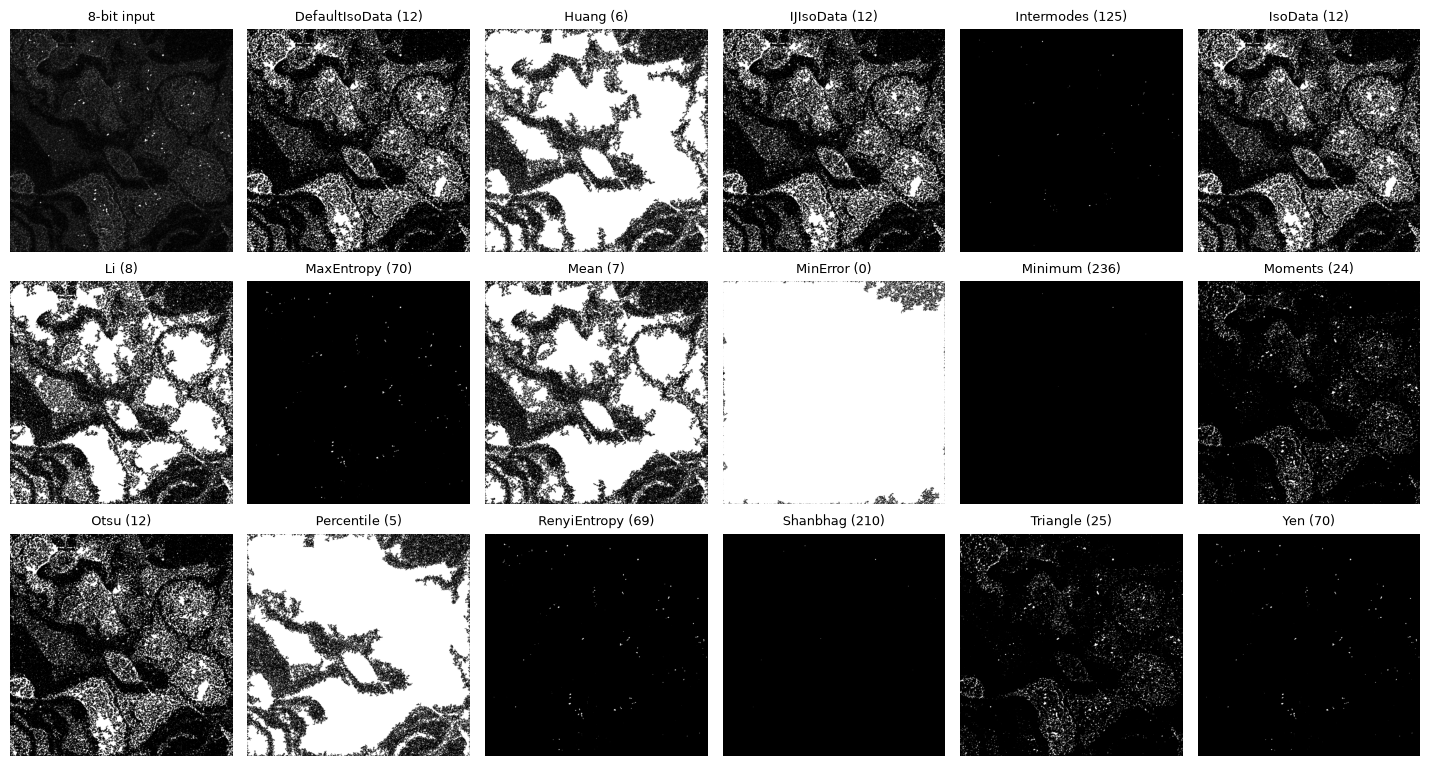

In [19]:
# --- Steps 1-6, then every ImageJ auto-threshold method ------------------------------
raw_projection, input_8bit = preprocess(IMAGE_PATH, PARAMS)
threshold_levels = all_thresholds(input_8bit)

# --- Fill holes in each mask (ImageJ Binary > Fill Holes) ---------------------------
usable_methods = [(name, level) for name, level in threshold_levels.items() if level >= 0]
method_masks = {name: fill_holes(input_8bit > level) for name, level in usable_methods}

print(f"projection {input_8bit.shape}, 8-bit min/max {input_8bit.min()}/{input_8bit.max()}")
for name, level in threshold_levels.items():
    if level < 0:
        print(f"{name:<15} ->  no threshold found")
    else:
        print(f"{name:<15} -> {level:4d}   foreground {100 * method_masks[name].mean():6.2f}%")

# --- Plot the 8-bit input and every usable method's filled mask ---------------------
ncols = 6
nrows = -(-(len(usable_methods) + 1) // ncols)  # +1 for the input image
fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.6 * nrows))
axes = np.atleast_1d(axes).ravel()

vmin, vmax = contrast_limits(input_8bit)
axes[0].imshow(input_8bit, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("8-bit input", fontsize=9)
for ax, (name, level) in zip(axes[1:], usable_methods):
    ax.imshow(method_masks[name], cmap="gray")
    ax.set_title(f"{name} ({level})", fontsize=9)
for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Apply the chosen threshold and QC plot

Four panels, all auto-contrasted for display: raw max projection, 8-bit input, filled mask,
overlay. This is the same figure the batch script saves as `{base}_focimask-qc.png`.


MaxEntropy threshold level: 70   foreground 0.15%


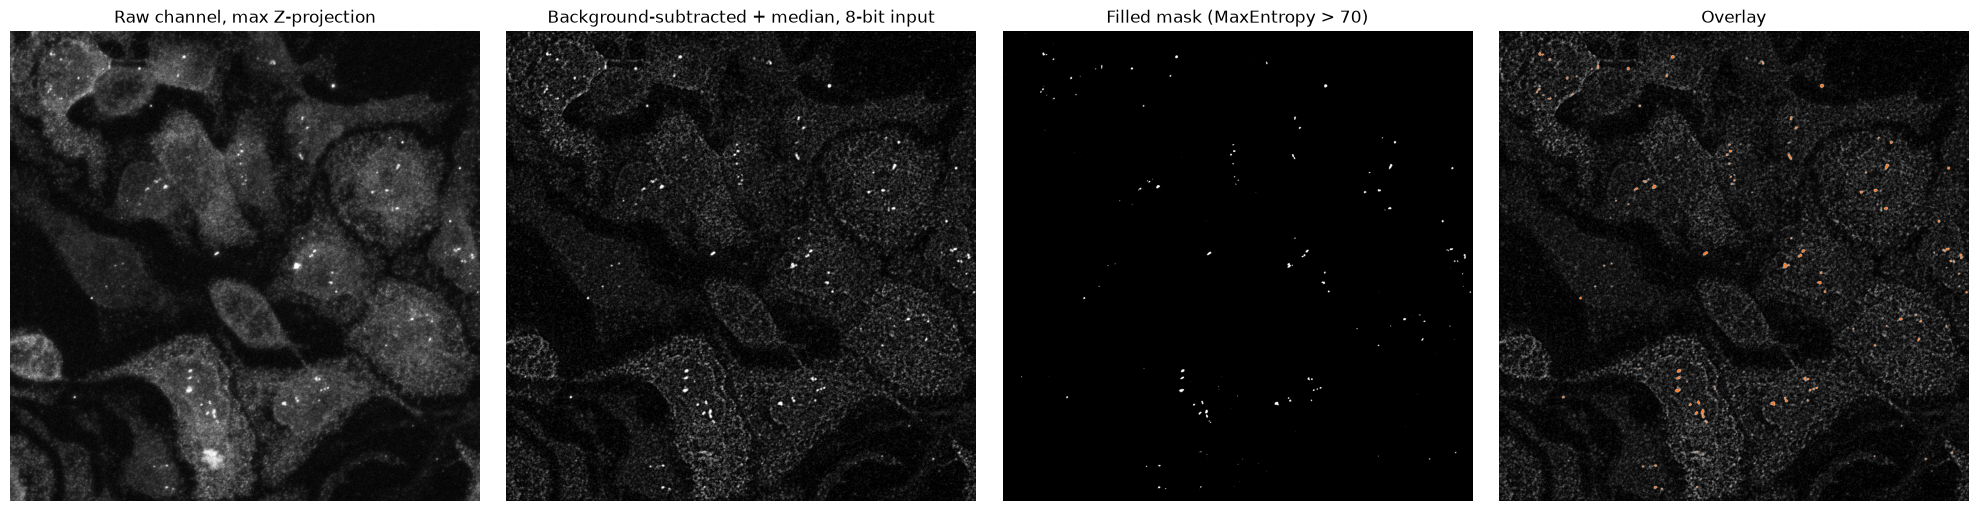

In [20]:
threshold_level, foci_mask = segment(input_8bit, THRESHOLD_METHOD)
print(f"{THRESHOLD_METHOD} threshold level: {threshold_level}"
      f"   foreground {100 * foci_mask.mean():.2f}%")

qc_figure(raw_projection, input_8bit, foci_mask, THRESHOLD_METHOD, threshold_level)
plt.show()


## Batch a folder

Once the method above looks right, apply it to every image in a folder with
`src/segment-hiv-transcription-foci-batch.py`. The **method** carries over, not the level:
the level is recomputed per image, so exposure differences between files are handled.

For each input it writes, into the output directory:

- `{base}_focimask.tif` -- uint8 0/255, so Fiji opens it as a binary mask
- `{base}_focimask-qc.png` -- the 4-panel plot above, to scan through for errors
- `focimask-summary.csv` -- one row per file (level, foreground %, error); sort it to find
  images the method treated differently from the rest

### Arguments

Only two are required -- the input folder and `-o`. Everything else has a default:

| Argument | Required | Default |
| --- | --- | --- |
| `input_dir` (positional) | **yes** | -- |
| `-o`, `--output-dir` | **yes** | -- |
| `-m`, `--method` | no | `MaxEntropy` |
| `-p`, `--pattern` | no | `*.tif` |
| `--mode` | no | `2d` (`3d` filters every slice first; ~5x slower) |
| `--channel-axis` / `--channel-index` / `--z-axis` | no | `1` / `0` / `0` |
| `--rolling-ball-radius` / `--median-radius` | no | `10` / `2` |
| `--dpi` | no | `110` |

So the shortest useful call, from a terminal **in this folder**, is:

```bash
uv run python src/segment-hiv-transcription-foci-batch.py <input_dir> -o <output_dir>
```

The defaults are the same values as `PARAMS` and `THRESHOLD_METHOD` at the top of this
notebook. **If you changed any of those while tuning, pass the matching flag** -- the script
does not read this notebook:

```bash
uv run python src/segment-hiv-transcription-foci-batch.py <input_dir> -o <output_dir> \
    -m Otsu --rolling-ball-radius 15 --median-radius 3
```

`--help` lists everything. One bad file logs its error to the CSV and the batch continues.

Or run it from here (edit the paths first):


In [ ]:
!uv run python src/segment-hiv-transcription-foci-batch.py \
    "/Volumes/Jeff-exFAT/Marko_HIV/110723/MARF1/Dox" \
    -o "/Volumes/Jeff-exFAT/Marko_HIV/110723/MARF1/Dox/foci_masks" \
    -m MaxEntropy
